# 02C: Sentiment-Enhanced K-Means + Regression

## Objective
Integrate news sentiment (FinBERT) into both clustering and stock price regression.

## What This Notebook Adds
1. Data collection: fetch stock-related headlines from yfinance and optional NewsAPI
2. Feature conversion: compute daily per-stock `sentiment_score` with FinBERT
3. K-Means optimization: include sentiment features in stock-level clustering
4. Regression optimization: include sentiment features for next-day price prediction

In [1]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost kagglehub yfinance transformers torch requests

import os
import time
import requests
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from xgboost import XGBRegressor

import yfinance as yf
from transformers import pipeline
import kagglehub

sns.set_palette('husl')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

print('[OK] Libraries loaded')

  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334


Note: you may need to restart the kernel to use updated packages.
[OK] Libraries loaded


In [2]:
# Resolve paths
cwd = Path.cwd()
REG_TASK = '02_stock_price_regression'
CLUSTER_TASK = '03_stock_clustering_analysis'

if cwd.name == 'implementation':
    reg_root = cwd.parent
elif cwd.name == REG_TASK:
    reg_root = cwd
elif (cwd / REG_TASK).exists():
    reg_root = cwd / REG_TASK
else:
    reg_root = cwd

workspace_root = reg_root.parent
cluster_root = workspace_root / CLUSTER_TASK
cluster_data_dir = cluster_root / 'data'

GRAPH_DIR = reg_root / 'graph'
GRAPH_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = reg_root / 'data'
DATA_DIR.mkdir(parents=True, exist_ok=True)

raw_cache = cluster_data_dir / 'sp500_raw.csv'
cluster_assign_path = cluster_data_dir / '03A_stock_cluster_assignments.csv'
cluster_summary_path = cluster_data_dir / '03A_cluster_feature_summary.csv'

print(f'Regression root: {reg_root}')
print(f'Cluster data dir: {cluster_data_dir}')

Regression root: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\02_stock_price_regression
Cluster data dir: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\03_stock_clustering_analysis\data


In [3]:
# Load base market data and 03A cluster outputs
if raw_cache.exists():
    data = pd.read_csv(raw_cache)
    print('[CACHE] Loaded shared raw cache')
else:
    path = kagglehub.dataset_download('camnugent/sandp500')
    csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
    data = pd.read_csv(os.path.join(path, csv_file))

if not cluster_assign_path.exists() or not cluster_summary_path.exists():
    raise FileNotFoundError('Please run 03A_KMeans_Clustering.ipynb first to generate required files.')

cluster_assign = pd.read_csv(cluster_assign_path)
cluster_summary = pd.read_csv(cluster_summary_path)

# Use all stocks from largest 3 clusters
cluster_stock_map = cluster_assign[['Name', 'cluster']].drop_duplicates()
cluster_size = cluster_stock_map.groupby('cluster')['Name'].nunique().sort_values(ascending=False)
top_clusters = cluster_size.head(3).index.astype(int).tolist()
top_clusters_sorted = sorted(top_clusters)

available_symbols = set(data['Name'].unique())
selected = sorted(
    s for s in cluster_stock_map[cluster_stock_map['cluster'].isin(top_clusters)]['Name'].unique()
    if s in available_symbols
)

if not selected:
    raise ValueError('No overlapping symbols found between market data and top clusters.')

data = data[data['Name'].isin(selected)].copy()
data['date'] = pd.to_datetime(data['date'])

print(f'Selected clusters: {', '.join(map(str, top_clusters_sorted))}')
print(f'Selected stocks: {len(selected)}')
print(f'Market rows: {len(data)}')

[CACHE] Loaded shared raw cache
Selected clusters: 0, 1, 4
Selected stocks: 496
Market rows: 607993


## Step 1: News Data Fetching (yfinance + optional NewsAPI)

Notes:
- `yfinance` news is used by default (free, no key).
- NewsAPI is optional. Set environment variable `NEWSAPI_KEY` to enable.
- Historical news coverage depends on provider availability.

In [4]:
# News fetch controls
NEWS_STOCK_LIMIT = 120   # set None to use all selected stocks (slow)
MAX_NEWS_PER_STOCK = 50
SLEEP_SEC = 0.05
USE_NEWSAPI = True
NEWSAPI_KEY = os.getenv('NEWSAPI_KEY', '').strip()

symbols_for_news = selected if NEWS_STOCK_LIMIT is None else selected[:NEWS_STOCK_LIMIT]

def safe_ts_to_date(ts):
    if ts is None or pd.isna(ts):
        return pd.NaT
    return pd.to_datetime(datetime.fromtimestamp(int(ts), tz=timezone.utc).date())

def fetch_yfinance_news(symbol, max_items=50):
    yf_symbol = symbol.replace('.', '-')
    rows = []
    try:
        items = yf.Ticker(yf_symbol).news or []
    except Exception:
        items = []

    for it in items[:max_items]:
        title = it.get('title', '')
        ts = it.get('providerPublishTime', None)
        d = safe_ts_to_date(ts)
        if title and pd.notna(d):
            rows.append({
                'Name': symbol,
                'date': d,
                'headline': title,
                'source': 'yfinance'
            })
    return rows

def fetch_newsapi_news(symbol, api_key, page_size=30):
    if not api_key:
        return []

    url = 'https://newsapi.org/v2/everything'
    params = {
        'q': f'{symbol} stock',
        'language': 'en',
        'sortBy': 'publishedAt',
        'pageSize': page_size,
        'apiKey': api_key
    }

    rows = []
    try:
        r = requests.get(url, params=params, timeout=15)
        payload = r.json() if r.ok else {}
        articles = payload.get('articles', [])
    except Exception:
        articles = []

    for a in articles:
        title = a.get('title', '')
        p = a.get('publishedAt', None)
        try:
            d = pd.to_datetime(p).normalize() if p else pd.NaT
        except Exception:
            d = pd.NaT
        if title and pd.notna(d):
            rows.append({
                'Name': symbol,
                'date': d,
                'headline': title,
                'source': 'newsapi'
            })
    return rows

news_rows = []
for i, sym in enumerate(symbols_for_news, start=1):
    news_rows.extend(fetch_yfinance_news(sym, max_items=MAX_NEWS_PER_STOCK))
    if USE_NEWSAPI and NEWSAPI_KEY:
        news_rows.extend(fetch_newsapi_news(sym, NEWSAPI_KEY, page_size=20))

    if i % 25 == 0:
        print(f'Fetched news for {i}/{len(symbols_for_news)} symbols')
    time.sleep(SLEEP_SEC)

news_df = pd.DataFrame(news_rows)
if len(news_df) == 0:
    print('[WARN] No headlines collected; sentiment will default to neutral (0).')
else:
    news_df = news_df.drop_duplicates(subset=['Name', 'date', 'headline']).reset_index(drop=True)
    print(f'Collected headlines: {len(news_df)}')
    print(news_df[['Name', 'date', 'source']].head())

Fetched news for 25/120 symbols
Fetched news for 50/120 symbols
Fetched news for 75/120 symbols
Fetched news for 100/120 symbols
[WARN] No headlines collected; sentiment will default to neutral (0).


## Step 2: FinBERT Sentiment Scoring

Generate daily per-stock `sentiment_score` using `ProsusAI/finbert`.

In [5]:
if len(news_df) == 0:
    sentiment_daily = pd.DataFrame(columns=['Name', 'date', 'sentiment_score', 'headline_count'])
else:
    sentiment_pipe = pipeline('sentiment-analysis', model='ProsusAI/finbert', truncation=True)

    def label_to_score(label):
        m = str(label).lower()
        if 'positive' in m:
            return 1.0
        if 'negative' in m:
            return -1.0
        return 0.0

    batch_size = 32
    scores = []
    texts = news_df['headline'].astype(str).tolist()

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        preds = sentiment_pipe(batch)
        scores.extend([label_to_score(p.get('label', 'neutral')) for p in preds])

    news_df['sentiment_raw'] = scores

    sentiment_daily = (
        news_df.groupby(['Name', 'date'])['sentiment_raw']
        .agg(['mean', 'count'])
        .reset_index()
        .rename(columns={'mean': 'sentiment_score', 'count': 'headline_count'})
    )

sentiment_path = DATA_DIR / '02C_daily_sentiment_scores.csv'
sentiment_daily.to_csv(sentiment_path, index=False)
print(f'[OK] Saved: {sentiment_path.name}')
print(f'Sentiment daily rows: {len(sentiment_daily)}')

[OK] Saved: 02C_daily_sentiment_scores.csv
Sentiment daily rows: 0


## Step 3: Feature Engineering + Sentiment Merge

Merge sentiment into price features and create sentiment lag/rolling features.

In [6]:
data = data.sort_values(['Name', 'date']).reset_index(drop=True)

def create_features(stock_df):
    stock_df = stock_df.sort_values('date').reset_index(drop=True).copy()

    stock_df['target'] = stock_df['close'].shift(-1)
    stock_df['price_range'] = (stock_df['high'] - stock_df['low']) / stock_df['open']
    stock_df['close_open_diff'] = (stock_df['close'] - stock_df['open']) / stock_df['open']
    stock_df['high_low_ratio'] = stock_df['high'] / stock_df['low']
    stock_df['daily_return'] = stock_df['close'].pct_change()
    stock_df['lag_return_1'] = stock_df['daily_return'].shift(1)
    stock_df['lag_return_5'] = stock_df['close'].pct_change(5)
    stock_df['volume_norm'] = stock_df['volume'] / stock_df['volume'].rolling(20).mean()
    stock_df['volume_trend'] = (stock_df['volume'] - stock_df['volume'].rolling(20).mean()) / stock_df['volume'].rolling(20).mean()
    stock_df['close_ma5'] = stock_df['close'].rolling(5).mean()
    stock_df['close_ma20'] = stock_df['close'].rolling(20).mean()
    stock_df['close_ma50'] = stock_df['close'].rolling(50).mean()
    stock_df['momentum_5'] = (stock_df['close'] - stock_df['close'].shift(5)) / stock_df['close'].shift(5)
    stock_df['momentum_20'] = (stock_df['close'] - stock_df['close'].shift(20)) / stock_df['close'].shift(20)
    stock_df['volatility_20'] = stock_df['daily_return'].rolling(20).std()
    stock_df['volatility_60'] = stock_df['daily_return'].rolling(60).std()

    delta = stock_df['daily_return'].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    stock_df['rsi'] = 100 - (100 / (1 + rs))

    return stock_df

reg_df = pd.concat([create_features(data[data['Name'] == s]) for s in selected], ignore_index=True)
reg_df = reg_df.dropna().reset_index(drop=True)

cluster_map = cluster_assign[['Name', 'cluster']].drop_duplicates('Name')
reg_df = reg_df.merge(cluster_map, on='Name', how='left')
reg_df['cluster'] = reg_df['cluster'].astype(int)

sentiment_daily['date'] = pd.to_datetime(sentiment_daily['date']) if len(sentiment_daily) else pd.to_datetime([])
reg_df = reg_df.merge(sentiment_daily, on=['Name', 'date'], how='left')
reg_df['sentiment_score'] = reg_df['sentiment_score'].fillna(0.0)
reg_df['headline_count'] = reg_df['headline_count'].fillna(0.0)

reg_df = reg_df.sort_values(['Name', 'date']).reset_index(drop=True)
reg_df['sentiment_lag1'] = reg_df.groupby('Name')['sentiment_score'].shift(1).fillna(0.0)
reg_df['sentiment_ma3'] = reg_df.groupby('Name')['sentiment_score'].rolling(3).mean().reset_index(level=0, drop=True).fillna(0.0)

print(f'Regression rows after sentiment merge: {len(reg_df)}')
print(reg_df[['Name', 'date', 'cluster', 'sentiment_score', 'headline_count']].head())

Regression rows after sentiment merge: 577747
  Name       date  cluster sentiment_score headline_count
0    A 2013-05-07        0             0.0            0.0
1    A 2013-05-08        0             0.0            0.0
2    A 2013-05-09        0             0.0            0.0
3    A 2013-05-10        0             0.0            0.0
4    A 2013-05-13        0             0.0            0.0


## Step 4: Sentiment-Enhanced K-Means

Add sentiment statistics into stock-level clustering profiles.

[OK] Saved: 02C_sentiment_kmeans_stock_assignments.csv


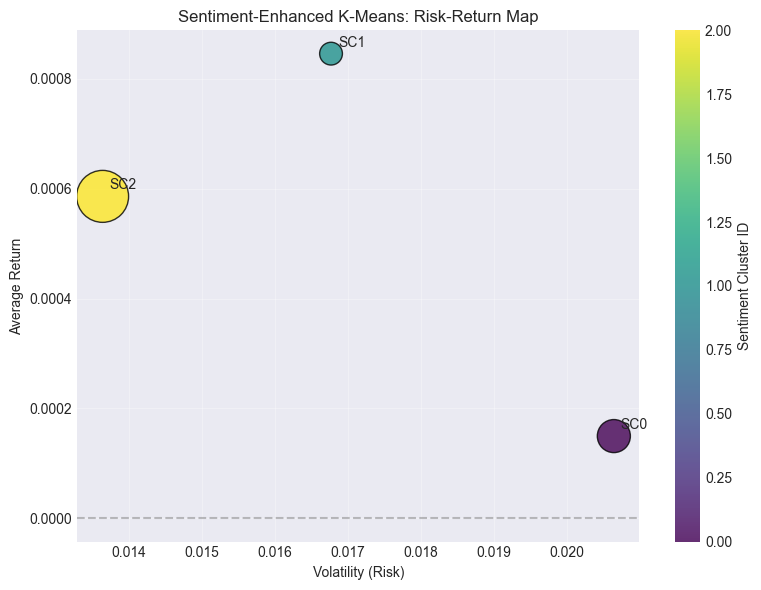

[OK] Saved: 11_sentiment_kmeans_risk_return_map.png


In [7]:
stock_profile = reg_df.groupby('Name').agg(
    volatility=('daily_return', 'std'),
    avg_return=('daily_return', 'mean'),
    avg_volume=('volume', 'mean'),
    volume_volatility=('volume', 'std'),
    momentum=('momentum_20', 'mean'),
    price_range=('price_range', 'mean'),
    trend_strength=('close_open_diff', 'mean'),
    price_level=('close', 'mean'),
    volume_to_price_ratio=('volume_norm', 'mean'),
    sentiment_mean=('sentiment_score', 'mean'),
    sentiment_std=('sentiment_score', 'std')
).fillna(0.0).reset_index()

cluster_features = [
    'volatility', 'avg_return', 'avg_volume', 'volume_volatility', 'momentum',
    'price_range', 'trend_strength', 'price_level', 'volume_to_price_ratio',
    'sentiment_mean', 'sentiment_std'
]

scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(stock_profile[cluster_features])

kmeans_sent = KMeans(n_clusters=3, random_state=42, n_init=20)
stock_profile['sent_cluster'] = kmeans_sent.fit_predict(X_km)

km_out = DATA_DIR / '02C_sentiment_kmeans_stock_assignments.csv'
stock_profile.to_csv(km_out, index=False)
print(f'[OK] Saved: {km_out.name}')

# Risk-return finance view for sentiment-enhanced clusters
finance_view = stock_profile.groupby('sent_cluster').agg(
    avg_return=('avg_return', 'mean'),
    volatility=('volatility', 'mean'),
    sentiment_mean=('sentiment_mean', 'mean'),
    n_stocks=('Name', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
size = (finance_view['n_stocks'] / finance_view['n_stocks'].max()) * 1200 + 200
sc = ax.scatter(finance_view['volatility'], finance_view['avg_return'], s=size, c=finance_view['sent_cluster'], cmap='viridis', alpha=0.8, edgecolors='black')
for _, r in finance_view.iterrows():
    ax.annotate(f"SC{int(r['sent_cluster'])}", (r['volatility'], r['avg_return']), xytext=(5, 5), textcoords='offset points')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Sentiment-Enhanced K-Means: Risk-Return Map')
ax.set_xlabel('Volatility (Risk)')
ax.set_ylabel('Average Return')
ax.grid(alpha=0.3)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Sentiment Cluster ID')
plt.tight_layout()
plt.savefig(str(GRAPH_DIR / '11_sentiment_kmeans_risk_return_map.png'), dpi=300, bbox_inches='tight')
plt.show()
print('[OK] Saved: 11_sentiment_kmeans_risk_return_map.png')

## Step 5: Sentiment-Enhanced Regression Comparison

Compare baseline regression vs sentiment-enhanced regression.

,MAE,RMSE,MAPE(%),R2
Baseline (No Sentiment),1.877567,11.025180,1.281335,0.978043
Sentiment-Enhanced,1.871287,10.992532,1.280437,0.978173


MAE improvement from sentiment: 0.33%


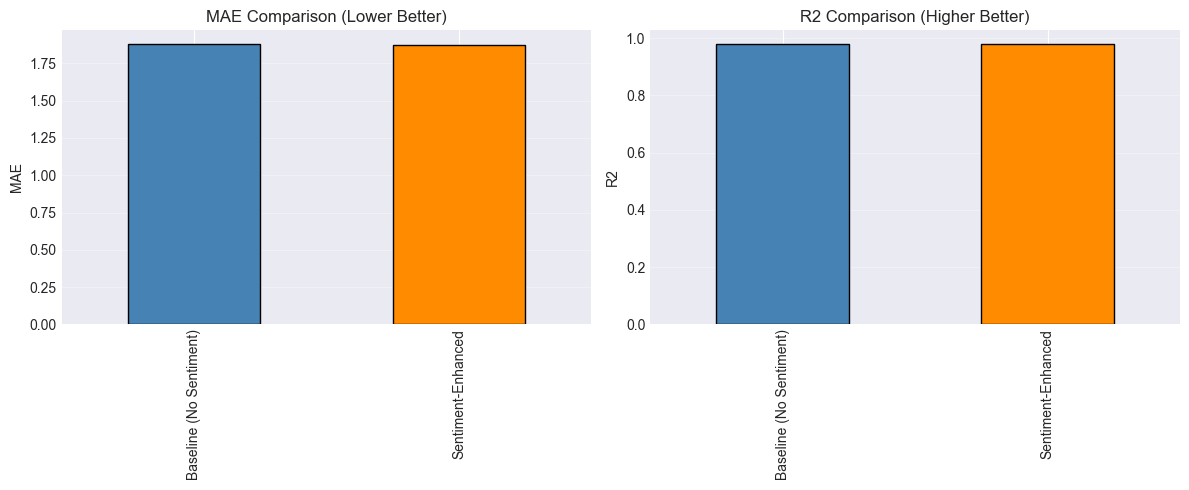

[OK] Saved: 12_sentiment_regression_comparison.png


In [8]:
base_features = [
    'price_range', 'close_open_diff', 'high_low_ratio', 'daily_return', 'lag_return_1', 'lag_return_5',
    'volume_norm', 'volume_trend', 'close_ma5', 'close_ma20', 'close_ma50',
    'momentum_5', 'momentum_20', 'volatility_20', 'volatility_60', 'rsi'
]
sent_features = base_features + ['sentiment_score', 'sentiment_lag1', 'sentiment_ma3', 'headline_count']

reg_df = reg_df.sort_values(['date', 'Name']).reset_index(drop=True)
split_date = reg_df['date'].quantile(0.8)
train_df = reg_df[reg_df['date'] <= split_date].copy()
test_df = reg_df[reg_df['date'] > split_date].copy()

X_train_base = train_df[base_features].fillna(0.0).values
X_test_base = test_df[base_features].fillna(0.0).values
X_train_sent = train_df[sent_features].fillna(0.0).values
X_test_sent = test_df[sent_features].fillna(0.0).values
y_train = train_df['target'].values
y_test = test_df['target'].values

sc_base = StandardScaler()
X_train_base = sc_base.fit_transform(X_train_base)
X_test_base = sc_base.transform(X_test_base)

sc_sent = StandardScaler()
X_train_sent = sc_sent.fit_transform(X_train_sent)
X_test_sent = sc_sent.transform(X_test_sent)

model_base = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, random_state=42, objective='reg:squarederror', n_jobs=-1)
model_sent = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, random_state=42, objective='reg:squarederror', n_jobs=-1)

model_base.fit(X_train_base, y_train)
model_sent.fit(X_train_sent, y_train)

pred_base = model_base.predict(X_test_base)
pred_sent = model_sent.predict(X_test_sent)

def eval_metrics(y_true, y_pred):
    return {
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAPE(%)': float(mean_absolute_percentage_error(y_true, y_pred) * 100),
        'R2': float(r2_score(y_true, y_pred))
    }

result_df = pd.DataFrame({
    'Baseline (No Sentiment)': eval_metrics(y_test, pred_base),
    'Sentiment-Enhanced': eval_metrics(y_test, pred_sent)
}).T

display(result_df)

improve_mae = (result_df.loc['Baseline (No Sentiment)', 'MAE'] - result_df.loc['Sentiment-Enhanced', 'MAE']) / result_df.loc['Baseline (No Sentiment)', 'MAE'] * 100
print(f'MAE improvement from sentiment: {improve_mae:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
result_df['MAE'].plot(kind='bar', ax=axes[0], color=['steelblue', 'darkorange'], edgecolor='black')
axes[0].set_title('MAE Comparison (Lower Better)')
axes[0].set_ylabel('MAE')
axes[0].grid(axis='y', alpha=0.3)

result_df['R2'].plot(kind='bar', ax=axes[1], color=['steelblue', 'darkorange'], edgecolor='black')
axes[1].set_title('R2 Comparison (Higher Better)')
axes[1].set_ylabel('R2')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(str(GRAPH_DIR / '12_sentiment_regression_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print('[OK] Saved: 12_sentiment_regression_comparison.png')

## Summary
- Added sentiment extraction pipeline from market headlines
- Integrated sentiment into K-Means (cluster profiling)
- Integrated sentiment into regression and compared metrics

If NewsAPI key is available, set `NEWSAPI_KEY` and rerun Step 1 for expanded coverage.